# Preprocessing for LA Buoy Network (LABN)
Station IDs: [46069, 46251, 46219, 46025, 46221] 
- real time data is borderline useless (too many missing data)
- data set up: train on 2022 and predict on 2023
- interpolation vs imputation: 
    - interpolate during dataframe EDA for easy modeling or,
    - do not interpolate (leaving NaNs as they are) and impute during modeling for running STGNN imputation experiments

In [254]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datetime import datetime
import folium

In [255]:
root_path = '../../experiments/data/raw/LA'
station46025_22 = pd.read_csv(f'{root_path}/46025h2022.txt', sep='\s+')
station46025_23 = pd.read_csv(f'{root_path}/46025h2023.txt', sep='\s+')
station46025_rt = pd.read_csv(f'{root_path}/46025RT.txt', sep='\s+')

station46069_22 = pd.read_csv(f'{root_path}/46069h2022.txt', sep='\s+')
station46069_23 = pd.read_csv(f'{root_path}/46069h2023.txt', sep='\s+')
station46069_rt = pd.read_csv(f'{root_path}/46069RT.txt', sep='\s+')

station46219_22 = pd.read_csv(f'{root_path}/46219h2022.txt', sep='\s+')
station46219_23 = pd.read_csv(f'{root_path}/46219h2023.txt', sep='\s+')
station46219_rt = pd.read_csv(f'{root_path}/46219RT.txt', sep='\s+')

station46221_22 = pd.read_csv(f'{root_path}/46221h2022.txt', sep='\s+')
station46221_23 = pd.read_csv(f'{root_path}/46221h2023.txt', sep='\s+')
station46221_rt = pd.read_csv(f'{root_path}/46221RT.txt', sep='\s+')

station46251_22 = pd.read_csv(f'{root_path}/46251h2022.txt', sep='\s+')
station46251_23 = pd.read_csv(f'{root_path}/46251h2023.txt', sep='\s+')
station46251_rt = pd.read_csv(f'{root_path}/46251RT.txt', sep='\s+')

/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_15632/2196052615.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  station46025_22 = pd.read_csv(f'{root_path}/46025h2022.txt', sep='\s+')
/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_15632/2196052615.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  station46025_23 = pd.read_csv(f'{root_path}/46025h2023.txt', sep='\s+')
/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_15632/2196052615.py:6: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  station46069_22 = pd.read_csv(f'{root_path}/46069h2022.txt', sep='\s+')
/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_15632/2196052615.py:7: DtypeWarning: Columns (0

In [256]:
dfs_train = [station46025_22, station46069_22, station46219_22, station46221_22, station46251_22]

dfs_test = [station46025_23, station46069_23, station46219_23, station46221_23, station46251_23]

df_rts = [station46025_rt, station46069_rt, station46219_rt, station46221_rt, station46251_rt]

In [257]:
for i, df in enumerate(dfs_train):
    df.drop(index=0, inplace=True)
    df.reset_index(drop=True, inplace=True)
    
for i, df in enumerate(dfs_test):
    df.drop(index=0, inplace=True)
    df.reset_index(drop=True, inplace=True)

for i, df in enumerate(df_rts):
    df.drop(index=0, inplace=True)
    df.reset_index(drop=True, inplace=True)

In [258]:
for i, df in enumerate(dfs_train):
    df.rename(columns={'#YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'}, inplace=True)
    df['time'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    df.drop(columns=['year', 'month', 'day', 'hour', 'minute'], inplace=True)
    df.drop(columns=['MWD', 'VIS', 'TIDE'], inplace=True)

for i, df in enumerate(dfs_test):
    df.rename(columns={'#YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'}, inplace=True)
    df['time'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    df.drop(columns=['year', 'month', 'day', 'hour', 'minute'], inplace=True)
    df.drop(columns=['MWD', 'VIS', 'TIDE'], inplace=True)

for i, df in enumerate(df_rts):
    df.rename(columns={'#YY': 'year', 'MM': 'month', 'DD': 'day', 'hh': 'hour', 'mm': 'minute'}, inplace=True)
    df['time'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
    df.drop(columns=['year', 'month', 'day', 'hour', 'minute'], inplace=True)
    df.drop(columns=['MWD', 'VIS', 'TIDE'], inplace=True)

In [259]:
def convert_to_float(df):
    included_columns = [col for col in df.columns if col != 'time']
    for col in included_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

In [260]:
dfs_train = [convert_to_float(df) for df in dfs_train]
dfs_test = [convert_to_float(df) for df in dfs_test]
df_rts = [convert_to_float(df) for df in df_rts]

In [261]:
def remove_invalid_wvht(df):
    df.set_index('time', inplace=True)
    
    df['WVHT'] = df['WVHT'].replace(99.0, np.nan)
    df['WVHT'] = df['WVHT'].interpolate(method='linear')
    
    df.reset_index(inplace=True)
    
    return df

In [262]:
dfs_train = [remove_invalid_wvht(df) for df in dfs_train]
dfs_test = [remove_invalid_wvht(df) for df in dfs_test]

In [263]:
# set to_interpolate to False if you don't want to interpolate (for STGNN data imputation)

def resample_to_h(df, to_interpolate=True):
    df.set_index('time', inplace=True)
    df_h = df.resample('h').mean()
    df_h.reset_index(inplace=True)
    
    if to_interpolate:
        df_h.interpolate(method='linear', inplace=True)
    
    return df_h

In [264]:
dfs_train = [resample_to_h(df) for df in dfs_train]
dfs_test = [resample_to_h(df) for df in dfs_test]

In [265]:
print("2022 data")
for i, df in enumerate(dfs_train):
    df.info()

print("2023 data")
for i, df in enumerate(dfs_test):
    df.info()

2022 data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    8760 non-null   datetime64[ns]
 1   WDIR    8760 non-null   float64       
 2   WSPD    8760 non-null   float64       
 3   GST     8760 non-null   float64       
 4   WVHT    8760 non-null   float64       
 5   DPD     8760 non-null   float64       
 6   APD     8760 non-null   float64       
 7   PRES    8760 non-null   float64       
 8   ATMP    8760 non-null   float64       
 9   WTMP    8760 non-null   float64       
 10  DEWP    8760 non-null   float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 752.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    8760 non-null   datetime64[ns]
 1   WDIR 

2022 data


/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_15632/988197624.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


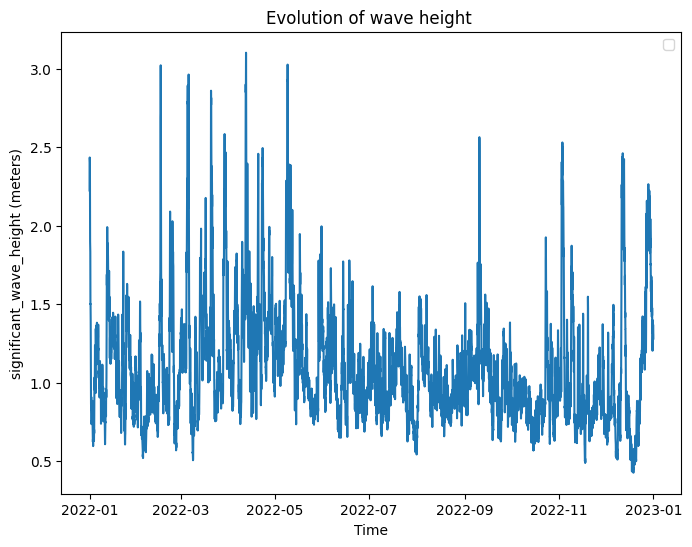

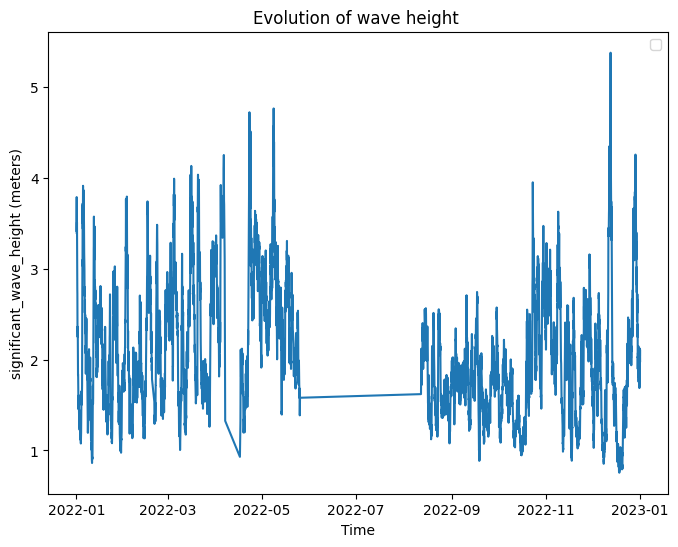

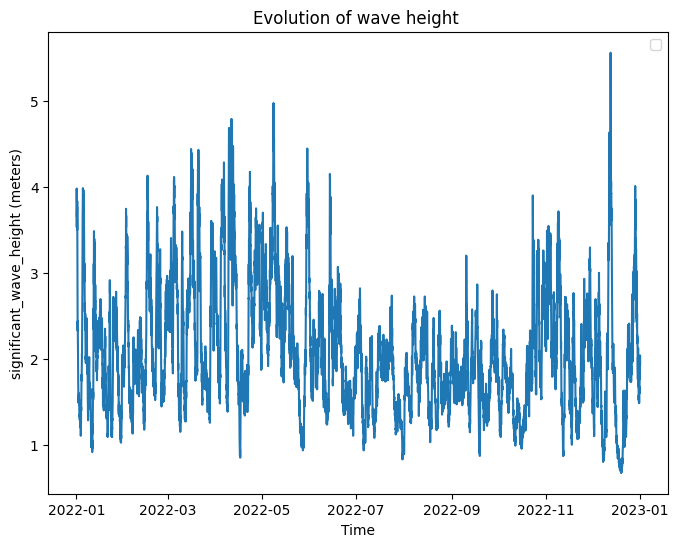

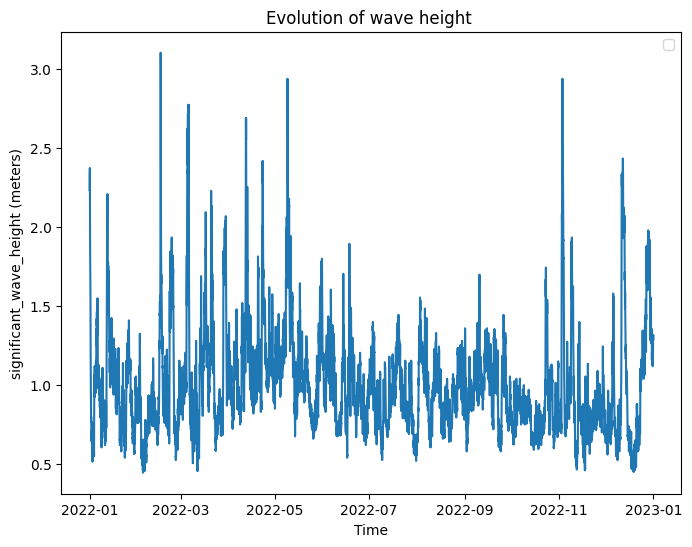

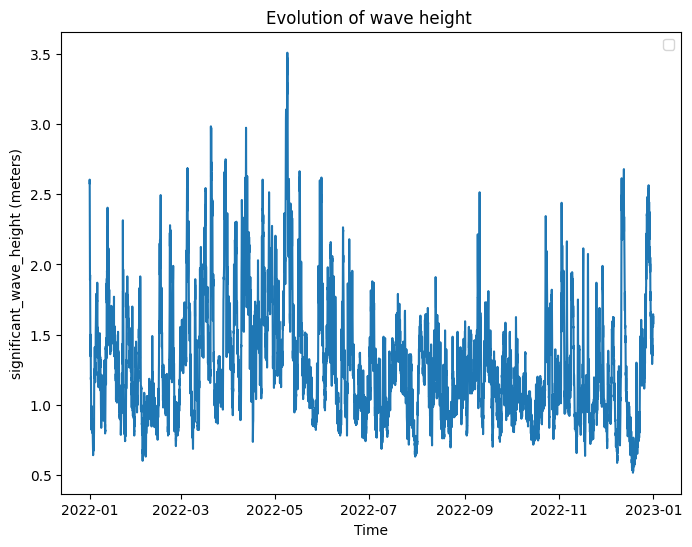

2023 data


/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_15632/988197624.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


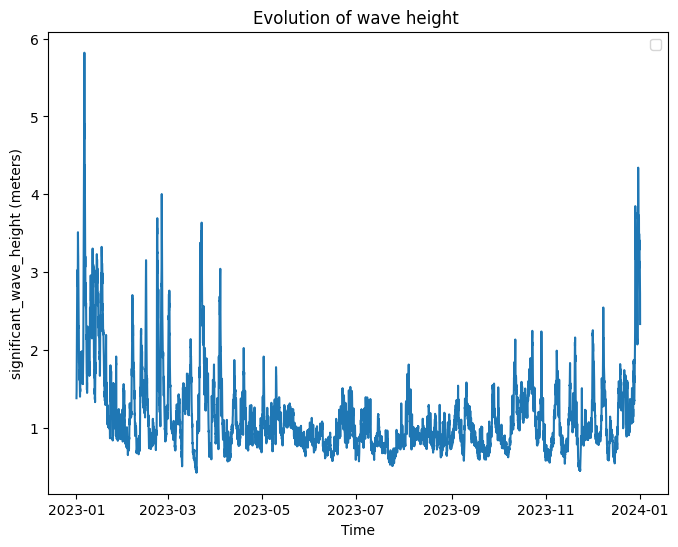

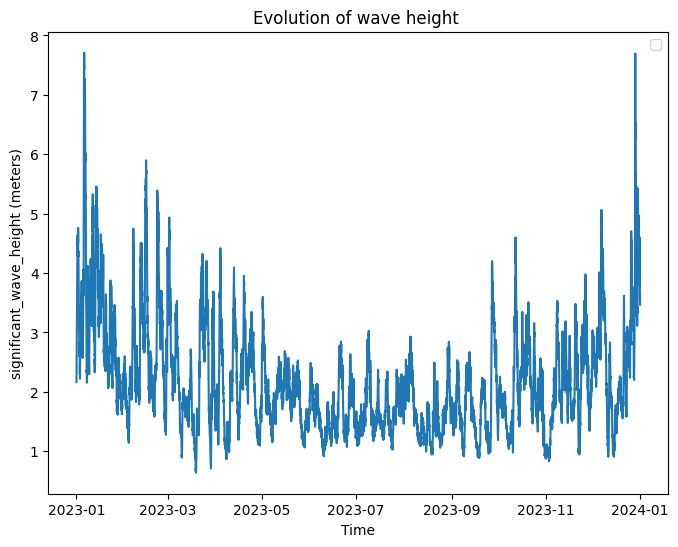

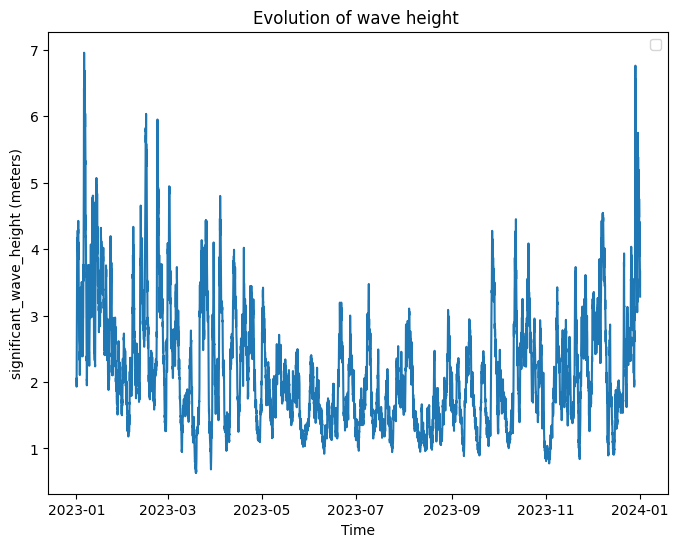

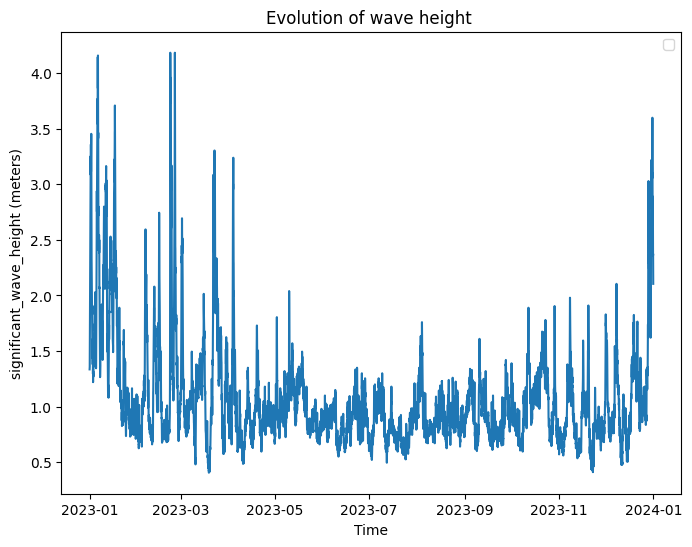

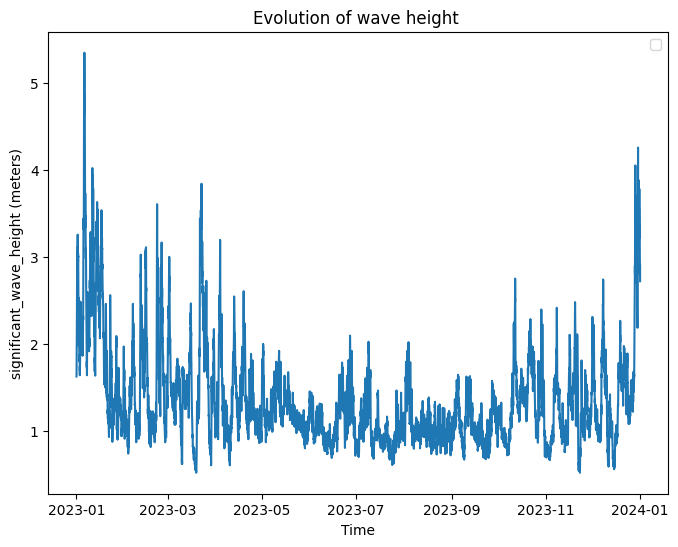

In [266]:
print("2022 data")
for i, df in enumerate(dfs_train):
    start_date = df['time'].min()
    # end_date = start_date + pd.DateOffset(hours=12)
    end_date = df['time'].max()

    df_slice = df[(df['time'] >= start_date) & (df['time'] <= end_date)]

    plt.figure(figsize=(8, 6))
    plt.plot(df_slice['time'], df_slice['WVHT'])

    plt.xlabel('Time')
    plt.ylabel('significant_wave_height (meters)')
    plt.title('Evolution of wave height ')
    plt.legend()

    plt.show()

print("2023 data")
for i, df in enumerate(dfs_test):
    start_date = df['time'].min()
    # end_date = start_date + pd.DateOffset(hours=12)
    end_date = df['time'].max()

    df_slice = df[(df['time'] >= start_date) & (df['time'] <= end_date)]

    plt.figure(figsize=(8, 6))
    plt.plot(df_slice['time'], df_slice['WVHT'])

    plt.xlabel('Time')
    plt.ylabel('significant_wave_height (meters)')
    plt.title('Evolution of wave height ')
    plt.legend()

    plt.show()

In [267]:
full_time_range_train = pd.date_range(
    start=min(df['time'].min() for df in dfs_train),
    end=max(df['time'].max() for df in dfs_train),
    freq='h'
)

full_time_range_test = pd.date_range(
    start=min(df['time'].min() for df in dfs_test),
    end=max(df['time'].max() for df in dfs_test),
    freq='h'
)

# Function to pad DataFrame to the full time range
def pad_dataframe(df, full_time_range):
    df = df.set_index('time').reindex(full_time_range).reset_index()
    df.columns = ['time'] + list(df.columns[1:])  # Rename the index column back to 'time'
    return df

len(full_time_range_train), len(full_time_range_test)

(8760, 8760)

In [268]:
# only execute this cell if you want to pad the dataframes for imputation. If interpolating, skip this cell
padded_dfs_train = [pad_dataframe(df, full_time_range_train) for df in dfs_train]
padded_dfs_test = [pad_dataframe(df, full_time_range_test) for df in dfs_test]

In [269]:
for i, df in enumerate(dfs_train):
    df['year'] = df['time'].dt.year
    df['month'] = df['time'].dt.month
    df['day'] = df['time'].dt.day
    df['hour'] = df['time'].dt.hour
    df['minute'] = df['time'].dt.minute

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24) 

    df.drop(columns=['year', 'month', 'day', 'hour', 'minute', 'time'], inplace=True)

for i, df in enumerate(dfs_test):
    df['year'] = df['time'].dt.year
    df['month'] = df['time'].dt.month
    df['day'] = df['time'].dt.day
    df['hour'] = df['time'].dt.hour
    df['minute'] = df['time'].dt.minute

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24) 

    df.drop(columns=['year', 'month', 'day', 'hour', 'minute', 'time'], inplace=True)

In [270]:
# station list: 46025 46069 46219 46221 46251

X_train = []
y_train = []
X_test = []
y_test = []
for i, df in enumerate(dfs_train):
    X_train.append(torch.tensor(df.values, dtype=torch.float32))
    y_train.append(torch.tensor(df['WVHT'].values, dtype=torch.float32).unsqueeze(1))

for i, df in enumerate(dfs_test):
    X_test.append(torch.tensor(df.values, dtype=torch.float32))
    y_test.append(torch.tensor(df['WVHT'].values, dtype=torch.float32).unsqueeze(1))

X_train = torch.stack(X_train, dim=1)
y_train = torch.stack(y_train, dim=1)
X_test = torch.stack(X_test, dim=1)
y_test = torch.stack(y_test, dim=1)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([8760, 5, 16]),
 torch.Size([8760, 5, 1]),
 torch.Size([8760, 5, 16]),
 torch.Size([8760, 5, 1]))

In [271]:
labn_dict = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test
}

save_path = '../../experiments/data/pt/group/labn.pt'
torch.save(labn_dict, save_path)

In [272]:
loaded_data = torch.load(save_path)

X_train = loaded_data['X_train']
y_train = loaded_data['y_train']
X_test = loaded_data['X_test']
y_test = loaded_data['y_test']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_15632/1624008449.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_data = torch.load(save_path)


(torch.Size([8760, 5, 16]),
 torch.Size([8760, 5, 1]),
 torch.Size([8760, 5, 16]),
 torch.Size([8760, 5, 1]))